# Importing Libraries

In [43]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Import Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


import warnings
warnings.filterwarnings('ignore')

# Loading the dataset

In [17]:
df=pd.read_csv("/content/placementdata.csv")
df

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed


# Basic Data Exploration

In [18]:
# Display first 5 rows
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [19]:
# Display last 5 rows
df.tail()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
9995,9996,7.5,1,1,2,72,3.9,Yes,No,85,66,NotPlaced
9996,9997,7.4,0,1,0,90,4.8,No,No,84,67,Placed
9997,9998,8.4,1,3,0,70,4.8,Yes,Yes,79,81,Placed
9998,9999,8.9,0,3,2,87,4.8,Yes,Yes,71,85,Placed
9999,10000,8.4,0,1,1,66,3.8,No,No,62,66,NotPlaced


In [20]:
# Shape of dataset (Rows, Columns)
df.shape

(10000, 12)

In [21]:
# Column names
df.columns

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')

In [22]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [23]:
# Statistical Summary
df.describe()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [24]:
#check for missing (null) values
df.isnull()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False


In [25]:
# Check missing values
df.isnull().sum()

,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [26]:
# identify duplicate rows
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [27]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [28]:
# Check data types
df.dtypes

,0
StudentID,int64
CGPA,float64
Internships,int64
Projects,int64
Workshops/Certifications,int64
AptitudeTestScore,int64
SoftSkillsRating,float64
ExtracurricularActivities,object
PlacementTraining,object
SSC_Marks,int64


In [29]:
# Count unique values in each column
df.nunique()

,0
StudentID,10000
CGPA,27
Internships,3
Projects,4
Workshops/Certifications,4
AptitudeTestScore,31
SoftSkillsRating,19
ExtracurricularActivities,2
PlacementTraining,2
SSC_Marks,36


In [30]:
# Placement Status Count
df.value_counts()

,,,,,,,,,,,,count
StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus,
9984,6.6,2,1,0,60,4.1,Yes,No,61,66,NotPlaced,1
9983,7.7,0,2,2,90,4.8,Yes,Yes,60,87,Placed,1
9982,7.8,1,1,0,76,3.9,No,Yes,57,64,NotPlaced,1
9981,8.6,1,2,0,87,4.3,Yes,Yes,69,69,NotPlaced,1
9980,8.3,2,3,2,90,4.7,Yes,Yes,79,73,Placed,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed,1
4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed,1
3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced,1


In [31]:
df["PlacementStatus"].value_counts()

,count
PlacementStatus,
NotPlaced,5803
Placed,4197


# EDA

In [71]:
# Professional Plot Style

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["figure.dpi"] = 120

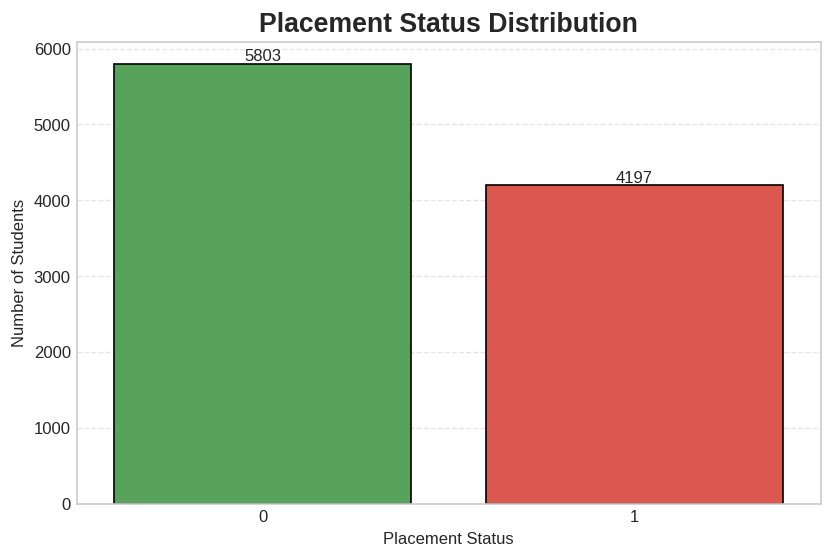

In [64]:
#Placement Status Distribution
plt.figure(figsize=(8,5))
ax = sns.countplot(x="PlacementStatus",data=df,palette=["#4CAF50","#F44336"],edgecolor="black")
plt.title("Placement Status Distribution",fontsize=16,fontweight="bold")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.grid(axis="y",linestyle="--",alpha=0.5)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

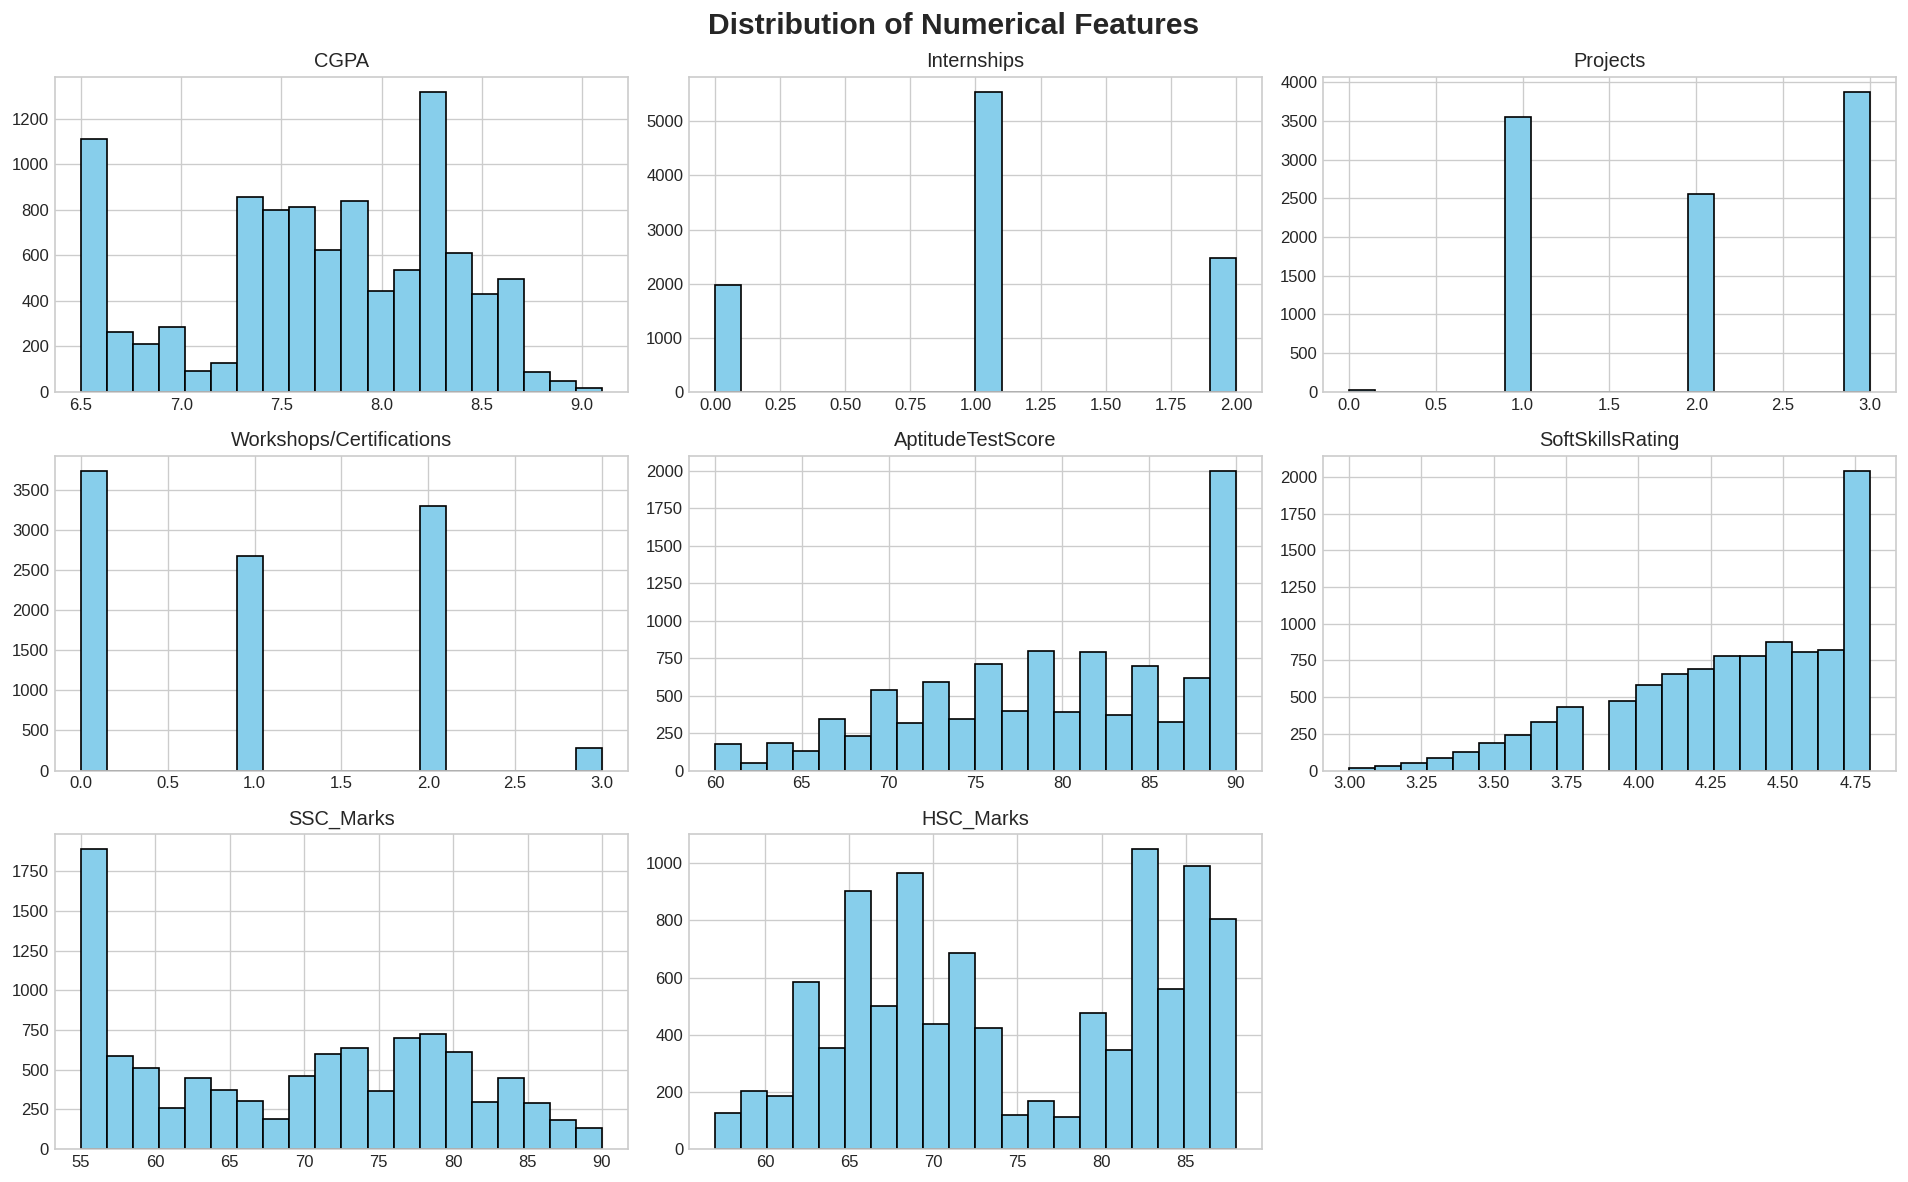

In [72]:
#Distribution of Numerical Features
numerical_cols = ["CGPA","Internships","Projects","Workshops/Certifications","AptitudeTestScore","SoftSkillsRating","SSC_Marks","HSC_Marks"]
df[numerical_cols].hist(figsize=(16,10),bins=20,edgecolor="black",color="skyblue")
plt.suptitle("Distribution of Numerical Features",fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

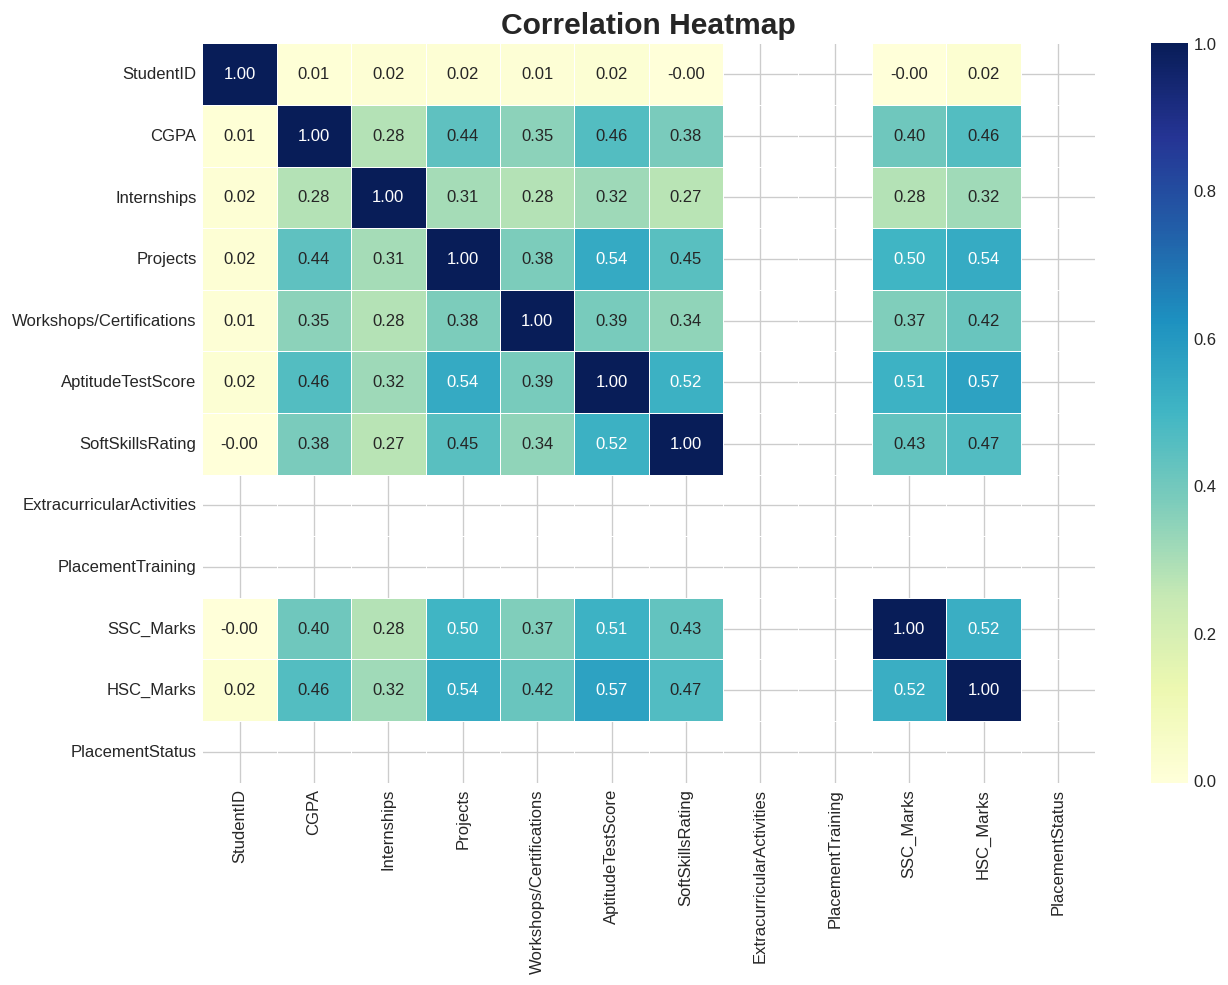

In [73]:
#Correlation Heatmap
df_heatmap = df.copy()
df_heatmap["ExtracurricularActivities"] = df_heatmap["ExtracurricularActivities"].map({"Yes":1,"No":0})
df_heatmap["PlacementTraining"] = df_heatmap["PlacementTraining"].map({"Yes":1,"No":0})
df_heatmap["PlacementStatus"] = df_heatmap["PlacementStatus"].map({"Placed":1,"NotPlaced":0})
plt.figure(figsize=(12,8))
sns.heatmap(df_heatmap.corr(),annot=True,cmap="YlGnBu",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap",fontsize=18,fontweight="bold")
plt.show()

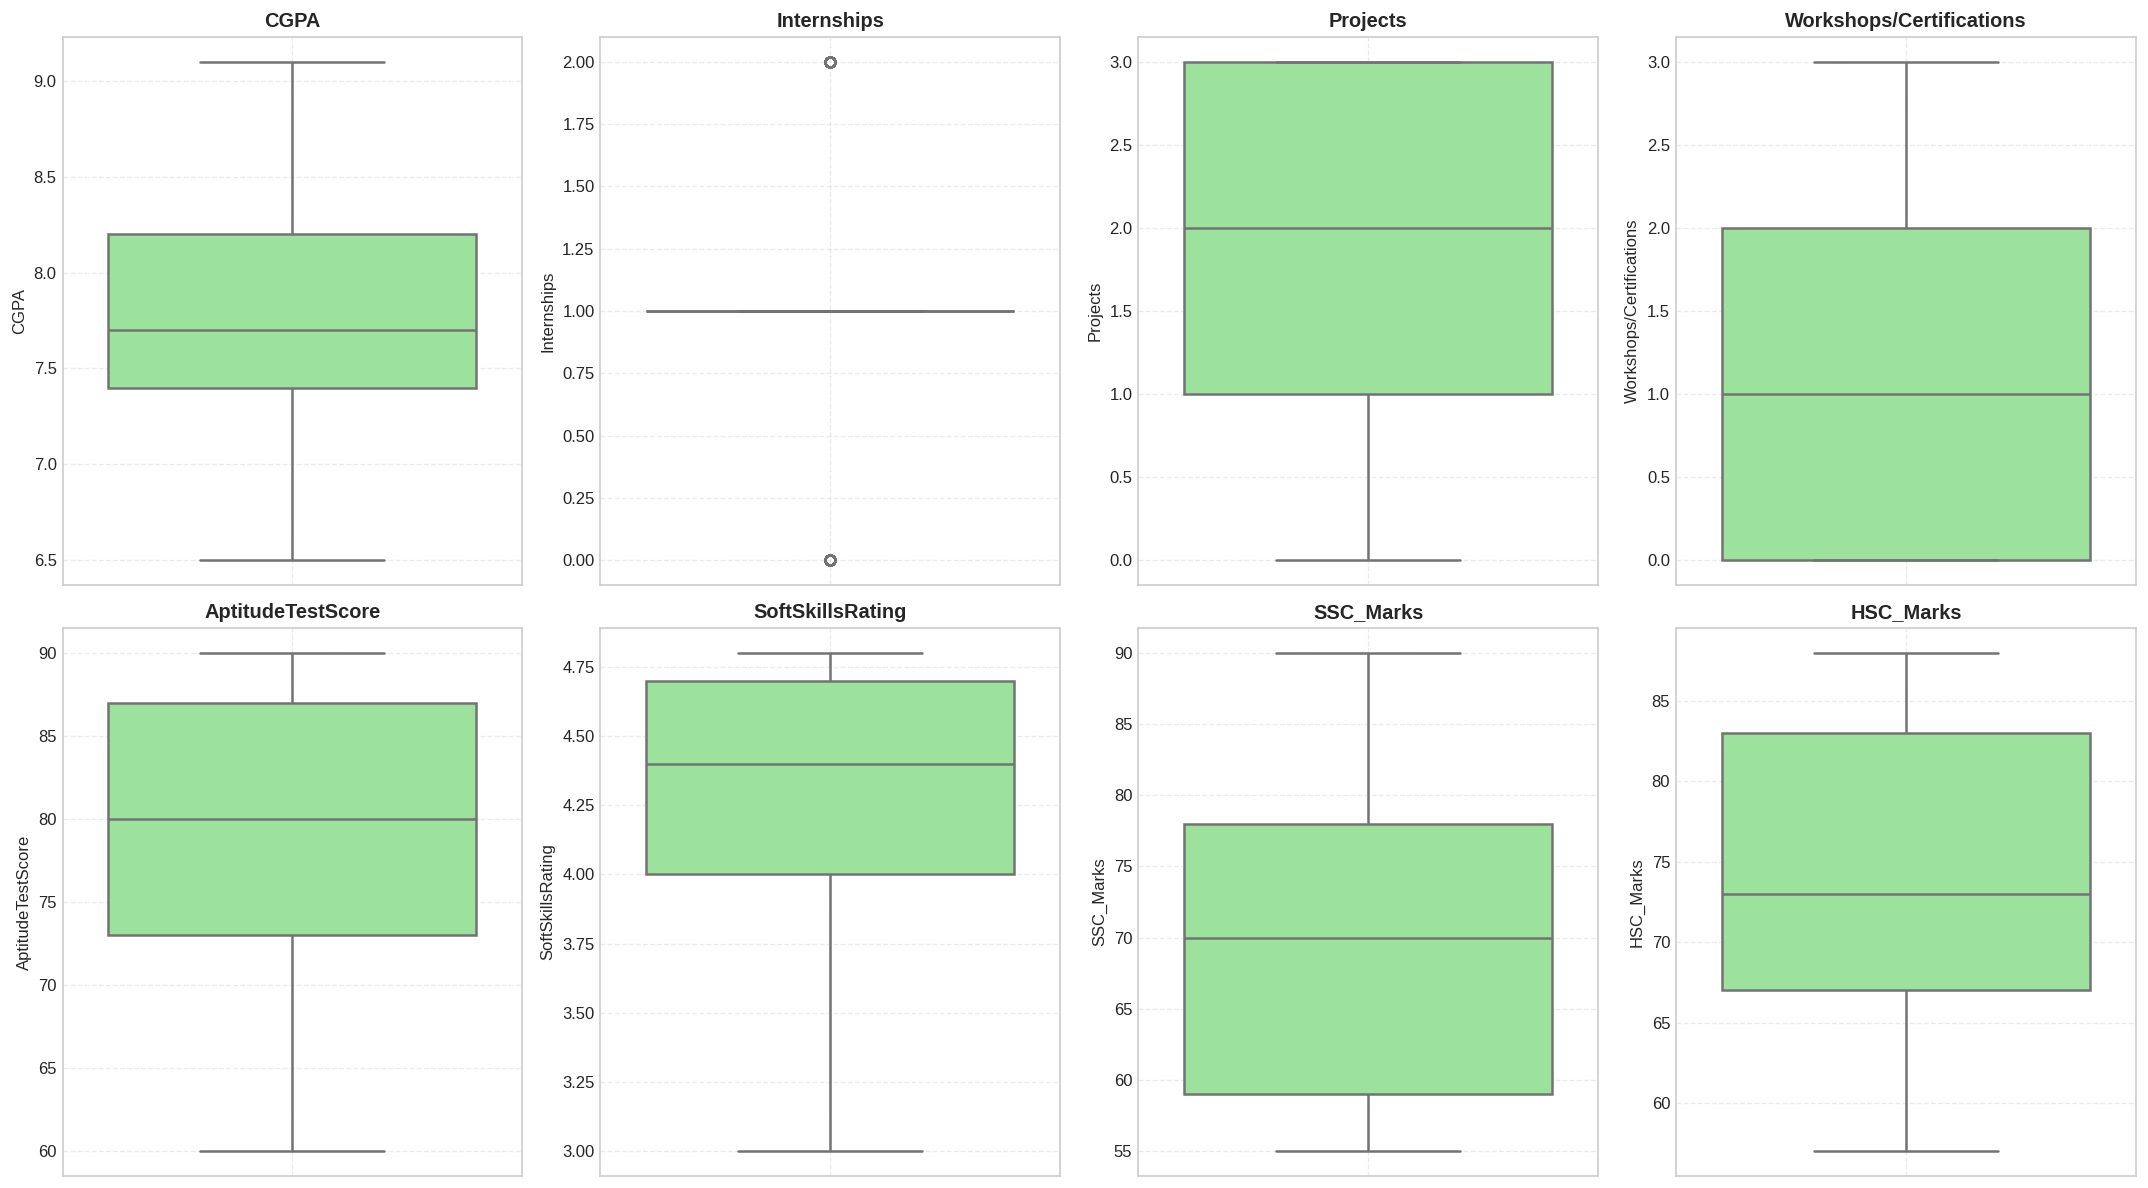

In [67]:
#Boxplots (Outlier Detection)
fig, axes = plt.subplots(2,4,figsize=(18,10))
for ax,col in zip(axes.flatten(),numerical_cols):
    sns.boxplot(y=df[col],color="lightgreen",linewidth=1.5,ax=ax)
    ax.set_title(col,fontweight="bold")
    ax.grid(ls="--",alpha=0.4)
plt.tight_layout()
plt.show()

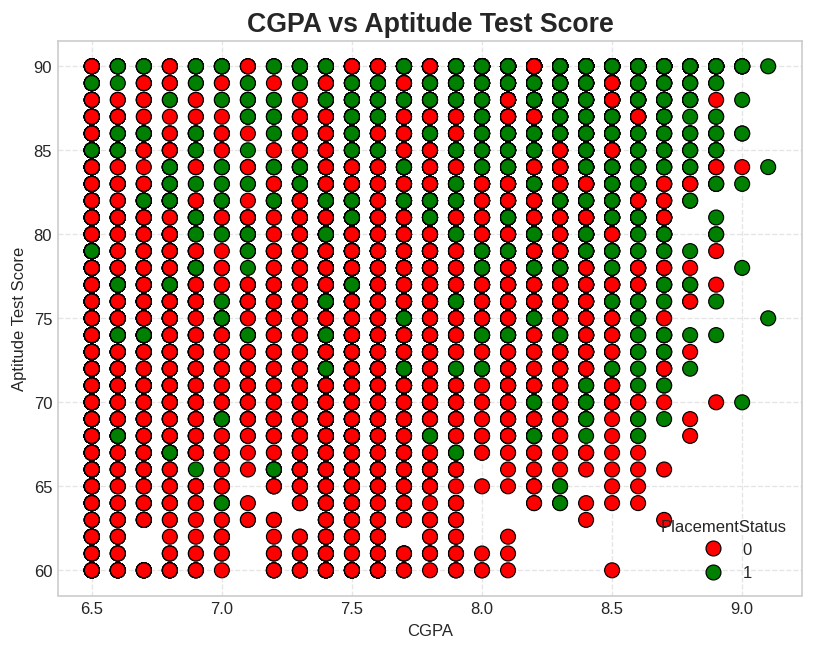

In [68]:
#Scatter Plot (CGPA vs Aptitude Score)
plt.figure(figsize=(8,6))
sns.scatterplot(x="CGPA",y="AptitudeTestScore",hue="PlacementStatus",data=df,palette=["red","green"],s=80,edgecolor="black")
plt.title("CGPA vs Aptitude Test Score",fontsize=16,fontweight="bold")
plt.xlabel("CGPA")
plt.ylabel("Aptitude Test Score")
plt.grid(ls="--",alpha=0.5)
plt.show()

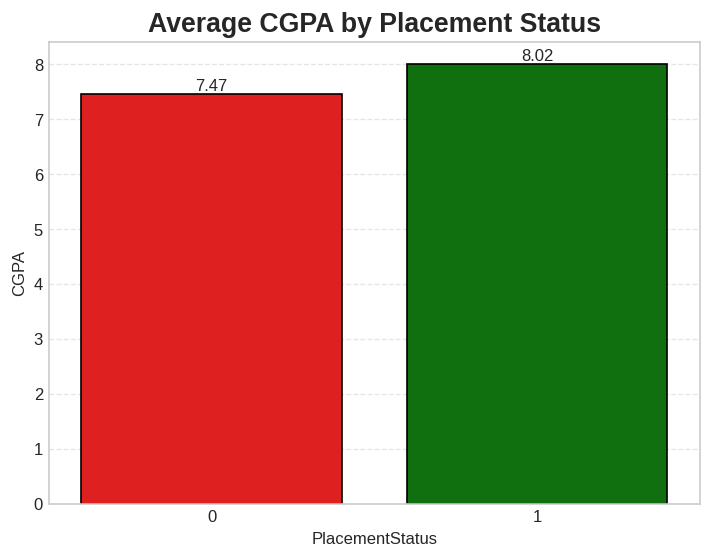

In [69]:
#Average CGPA by Placement Status
avg_cgpa = df.groupby("PlacementStatus")["CGPA"].mean().reset_index()
plt.figure(figsize=(7,5))
ax = sns.barplot(x="PlacementStatus",y="CGPA",data=avg_cgpa,palette=["red","green"],edgecolor="black")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.title("Average CGPA by Placement Status",fontsize=16,fontweight="bold")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.show()

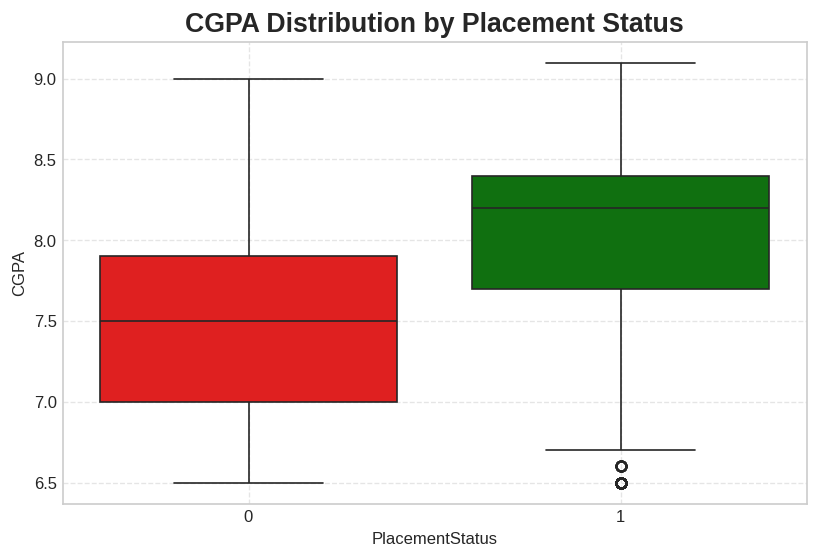

In [74]:
# comapres CGPA distributions of placed and not placed students
plt.figure(figsize=(8,5))
sns.boxplot(x="PlacementStatus",y="CGPA",data=df,palette=["red","green"])
plt.title("CGPA Distribution by Placement Status",fontsize=16,fontweight="bold")
plt.grid(ls="--",alpha=0.5)
plt.show()

# Data Preprocessing

In [39]:
#encode categorical columns
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['ExtracurricularActivities']=le.fit_transform(df['ExtracurricularActivities'])
df['PlacementTraining']=le.fit_transform(df['PlacementTraining'])
df['PlacementStatus']=le.fit_transform(df['PlacementStatus'])

df

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,0,0,61,79,0
1,2,8.9,0,3,2,90,4.0,1,1,78,82,1
2,3,7.3,1,2,2,82,4.8,1,0,79,80,0
3,4,7.5,1,1,2,85,4.4,1,1,81,80,1
4,5,8.3,1,2,2,86,4.5,1,1,74,88,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7.5,1,1,2,72,3.9,1,0,85,66,0
9996,9997,7.4,0,1,0,90,4.8,0,0,84,67,1
9997,9998,8.4,1,3,0,70,4.8,1,1,79,81,1
9998,9999,8.9,0,3,2,87,4.8,1,1,71,85,1


In [36]:
#define x and y
x=df.drop(columns=['PlacementStatus', 'StudentID'],axis=1)
y=df['PlacementStatus']

In [37]:
x

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
0,7.5,1,1,1,65,4.4,No,No,61,79
1,8.9,0,3,2,90,4.0,Yes,Yes,78,82
2,7.3,1,2,2,82,4.8,Yes,No,79,80
3,7.5,1,1,2,85,4.4,Yes,Yes,81,80
4,8.3,1,2,2,86,4.5,Yes,Yes,74,88
...,...,...,...,...,...,...,...,...,...,...
9995,7.5,1,1,2,72,3.9,Yes,No,85,66
9996,7.4,0,1,0,90,4.8,No,No,84,67
9997,8.4,1,3,0,70,4.8,Yes,Yes,79,81
9998,8.9,0,3,2,87,4.8,Yes,Yes,71,85


In [38]:
y

,PlacementStatus
0,NotPlaced
1,Placed
2,NotPlaced
3,Placed
4,Placed
...,...
9995,NotPlaced
9996,Placed
9997,Placed
9998,Placed


# Train-Test Split

In [40]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks
9254,8.0,1,3,3,87,4.6,Yes,No,83,88
1561,7.6,1,2,1,87,3.8,Yes,Yes,61,85
1670,8.2,1,3,2,86,4.4,Yes,Yes,76,65
6087,7.7,1,1,0,64,4.1,No,No,55,59
6669,8.5,2,3,2,90,4.8,Yes,No,80,87
...,...,...,...,...,...,...,...,...,...,...
5734,6.5,1,1,0,72,4.8,No,No,68,70
5191,7.4,1,1,0,67,4.1,No,Yes,60,73
5390,7.4,1,1,0,71,4.3,Yes,Yes,55,66
860,8.0,1,1,0,84,3.9,Yes,No,55,66


In [41]:
y_train

,PlacementStatus
9254,Placed
1561,NotPlaced
1670,Placed
6087,NotPlaced
6669,Placed
...,...
5734,NotPlaced
5191,NotPlaced
5390,NotPlaced
860,NotPlaced


# Feature Scaling

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Logistic Regression

In [48]:
model1 = LogisticRegression()
model1.fit(x_train,y_train)
y_pred1 = model1.predict(x_test)
print ("Logistic Accuracay:")
accuracy_score(y_test,y_pred1)

Logistic Accuracay:


0.7945

# KNN

In [54]:
model2 = KNeighborsClassifier()
model2.fit(x_train,y_train)
y_pred2 = model2.predict(x_test)
print ("KNN Accuracy:")
accuracy_score(y_test,y_pred2)

KNN Accuracy:


0.772

# Decision Tree

In [53]:
model3 = DecisionTreeClassifier()
model3.fit(x_train,y_train)
y_pred3 = model3.predict(x_test)
print ("Decision Tree Accuracy:")
accuracy_score(y_test,y_pred3)

Decision Tree Accuracy:


0.731

# Random Forest

In [57]:
model4 = RandomForestClassifier()
model4.fit(x_train,y_train)
y_pred4 = model4.predict(x_test)
print ("Random Forest Accuracy:")
accuracy_score(y_test,y_pred4)

Random Forest Accuracy:


0.7815

# Accuracy Comparison

In [58]:
result = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred1),
        accuracy_score(y_test,y_pred2),
        accuracy_score(y_test,y_pred3),
        accuracy_score(y_test,y_pred4)
    ]
})
print(result)

                 Model  Accuracy
0  Logistic Regression    0.7945
1                  KNN    0.7720
2        Decision Tree    0.7310
3        Random Forest    0.7815


In [59]:
best = result.loc[result['Accuracy'].idxmax()]
print("Best Model:", best["Model"])
print("Accuracy:", best["Accuracy"])

Best Model: Logistic Regression
Accuracy: 0.7945


In [60]:
print(confusion_matrix(y_test,y_pred4))
print(classification_report(y_test,y_pred4))

[[971 201]
 [236 592]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1172
           1       0.75      0.71      0.73       828

    accuracy                           0.78      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.78      0.78      0.78      2000



# Confusion Matrix

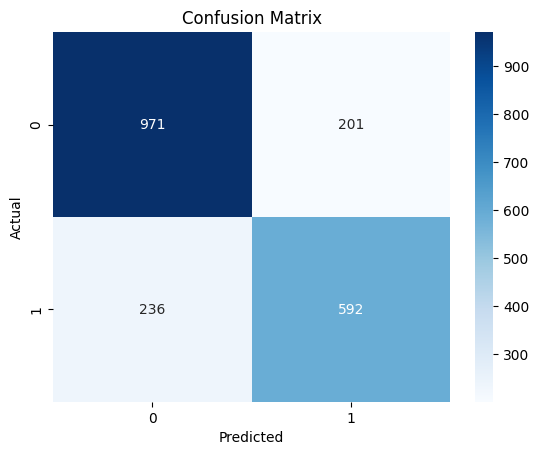

In [61]:
cm = confusion_matrix(y_test,y_pred4)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report

Text(0.5, 1.0, 'Model Accuracy Comparison')

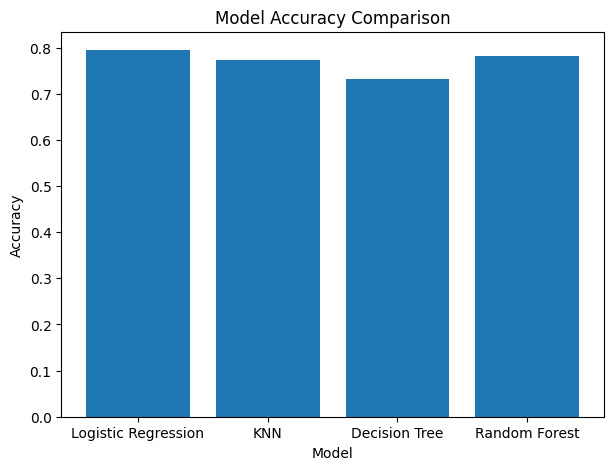

In [62]:
plt.figure(figsize=(7,5))
plt.bar(result["Model"],result["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")